In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"C:\kdt_0900_osh\ml\resource\datasets"
file_name = r"pulsar_star.csv"

file_path = os.path.join(base_path,file_name)
df = pd.read_csv(file_path)

# 펄서와 우주잡음의 분류(classification) 문제 - KNN이 필요한 모델
- 펄서 별(Pulsar Star) 데이터셋은 지구에 도착한 전파 관측 신호를 바탕으로 치이익- 하는 배경 우주 잡음과 진짜 펄서 별이 보내는 맥박 형태의 전파 신호를 구별하는 이진 분류(Binary Classification) 데이터셋입니다. 자전하며 주기적인 빔을 쏘는 펄서 특유의 물리적 성질 때문에, 일반 잡음과 달리 평균 신호 세기(signal_power)는 낮고 신호의 변동 폭(signal_spread)은 크게 튀는 독특한 데이터 분포를 가집니다.

### 펄서 별(Pulsar Star) 데이터셋 컬럼 명세

| 컬럼명 | 데이터 타입 | 설명 |
| :--- | :--- | :--- |
| **Mean of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **평균값** (신호의 전체적인 세기) |
| **Standard deviation of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **표준편차** (신호 세기의 변동폭) |
| **Excess kurtosis of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **첨도** (신호 분포의 뾰족함 정도) |
| **Skewness of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **왜도** (신호 분포의 치우침 정도) |
| **Mean of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **평균값** |
| **Standard deviation of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **표준편차** |
| **Excess kurtosis of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **첨도** |
| **Skewness of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **왜도** |
| **target_class** | Integer | **클래스 라벨 (0: 우주 잡음 / 1: 진짜 펄서 별)** |

In [3]:
df

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0
...,...,...,...,...,...,...,...,...,...
12523,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
12524,115.617188,46.784600,0.218177,0.226757,6.140468,NaN,5.732201,34.357283,0.0
12525,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
12526,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0


In [4]:
star_df = df[[" Mean of the integrated profile", " Standard deviation of the integrated profile", "target_class"]]

In [5]:
star_df

,Mean of the integrated profile,Standard deviation of the integrated profile,target_class
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [6]:
star_df.columns = ["signal_mean_power", "signal_spread", "target"]
star_df

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [7]:
star_df["target"].value_counts()

target
0.0    11375
1.0     1153
Name: count, dtype: int64

## 언더셈플링(데이터 불균형 해결)
- 더 많은 데이터 수를 더 적은 데이터 수에 맞추는 것.

In [8]:
df_0 = star_df[star_df["target"] == 0]
df_1 = star_df[star_df["target"] == 1]

df_0_sampled = df_0.sample(n=len(df_1),random_state=2026)
print(len(df_0_sampled))

1153


In [9]:
print(type(df_1), type(df_0_sampled))

<class 'pandas.DataFrame'> <class 'pandas.DataFrame'>


In [10]:
# pd.concat() : 두 데이터프레임을 합치는 함수
# reset_index(drop=True) : 기존 인덱스를 지우고 새로 인덱스 번호 부여
star_df = pd.concat([df_1, df_0_sampled]).sample(frac=1, random_state=2026).reset_index(drop=True)

In [11]:
star_df.head()

,signal_mean_power,signal_spread,target
0,138.820312,49.549602,0.0
1,25.437500,38.225636,1.0
2,34.023438,32.876299,1.0
3,101.093750,47.496289,0.0
4,101.945312,39.955309,0.0


### 사이킷런 KNN 분류 사이클 실습

In [12]:
star_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   signal_mean_power  2306 non-null   float64
 1   signal_spread      2306 non-null   float64
 2   target             2306 non-null   float64
dtypes: float64(3)
memory usage: 54.2 KB


In [13]:
star_df.describe()

,signal_mean_power,signal_spread,target
count,2306.000000,2306.000000,2306.000000
mean,87.201340,42.994349,0.500000
std,39.140325,8.200844,0.500108
min,5.812500,24.772042,0.000000
25%,54.300781,36.709625,0.000000
50%,96.570312,43.612955,0.500000
75%,118.986328,49.000045,1.000000
max,189.734375,90.250557,1.000000


In [14]:
star_df["target"] = star_df["target"].astype(int)
star_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   signal_mean_power  2306 non-null   float64
 1   signal_spread      2306 non-null   float64
 2   target             2306 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 54.2 KB


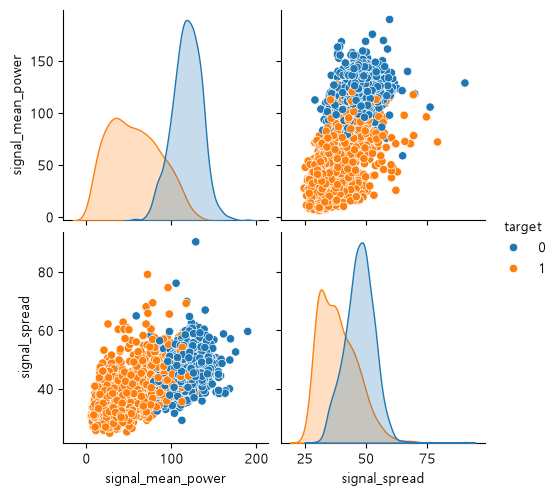

In [15]:
sns.pairplot(star_df, hue="target")

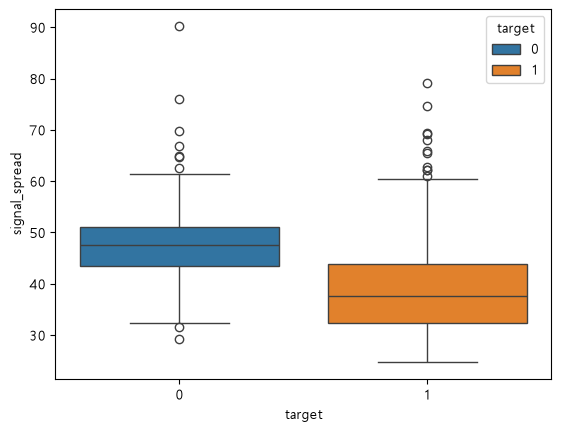

In [16]:
sns.boxplot(star_df, y="signal_spread", x="target", hue="target")
plt.show()

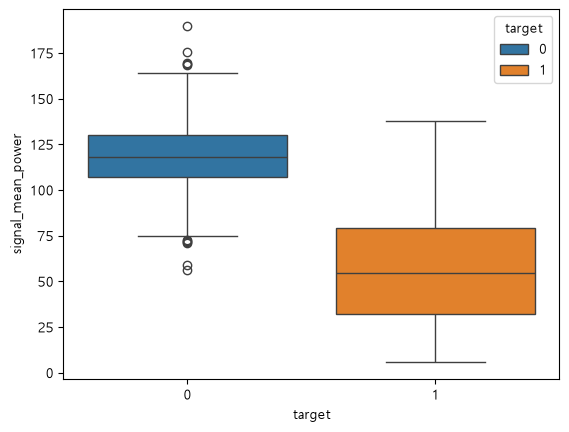

In [17]:
sns.boxplot(star_df, y="signal_mean_power", x="target", hue="target")
plt.show()

In [18]:
scaler1 = MinMaxScaler()

In [19]:
scaler = StandardScaler()

In [20]:
star_scaled = scaler.fit_transform(star_df[["signal_mean_power", "signal_spread"]])

In [21]:
star_scaled1 = scaler1.fit_transform(star_df[["signal_mean_power", "signal_spread"]])

In [22]:
star_scaled

array([[ 1.31910424,  0.79951218],
       [-1.57835264, -0.58161669],
       [-1.35894211, -1.23404921],
       ...,
       [-1.20461604, -1.49683237],
       [-1.18245538, -1.56034996],
       [ 0.85233278,  0.92142124]], shape=(2306, 2))

In [23]:
star_scaled1

array([[0.7231756 , 0.37840748],
       [0.10670291, 0.20546577],
       [0.15338544, 0.12376971],
       ...,
       [0.18622037, 0.09086462],
       [0.19093535, 0.0829111 ],
       [0.62386373, 0.39367264]], shape=(2306, 2))

In [24]:
star_df_scaled = pd.DataFrame(star_scaled,columns=["signal_mean_power", "signal_spread"])

In [25]:
star_df_scaled1 = pd.DataFrame(star_scaled1,columns=["signal_mean_power", "signal_spread"])

In [26]:
star_df_scaled["target"] = star_df["target"]

In [27]:
star_df_scaled1["target"] = star_df["target"]

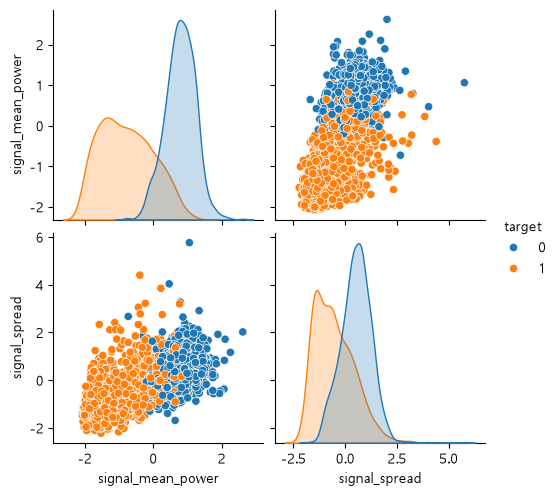

In [28]:
sns.pairplot(star_df_scaled, hue="target")

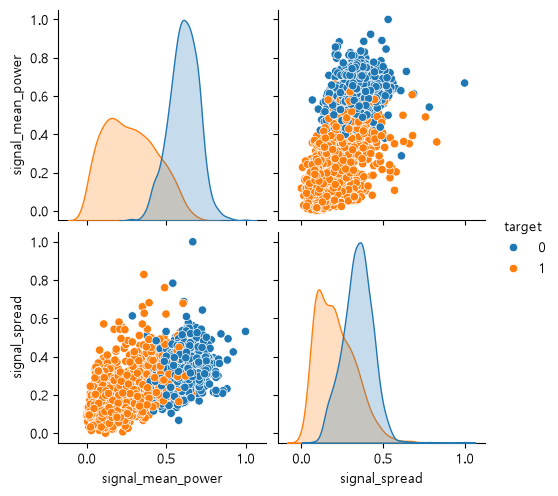

In [29]:
sns.pairplot(star_df_scaled1, hue="target")

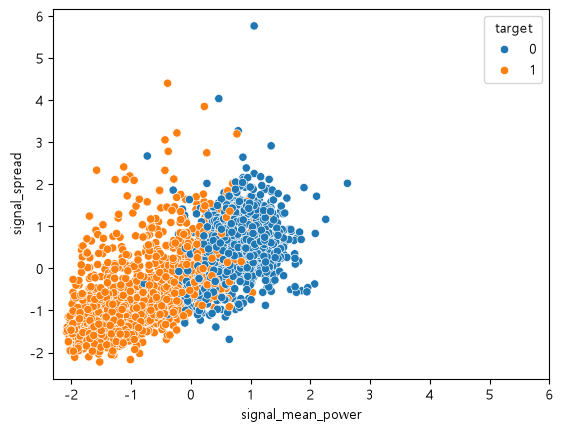

In [30]:
sns.scatterplot(star_df_scaled, x="signal_mean_power", y="signal_spread", hue="target")
plt.xlim(-2.3,6)
plt.show()

<Axes: xlabel='signal_mean_power', ylabel='signal_spread'>

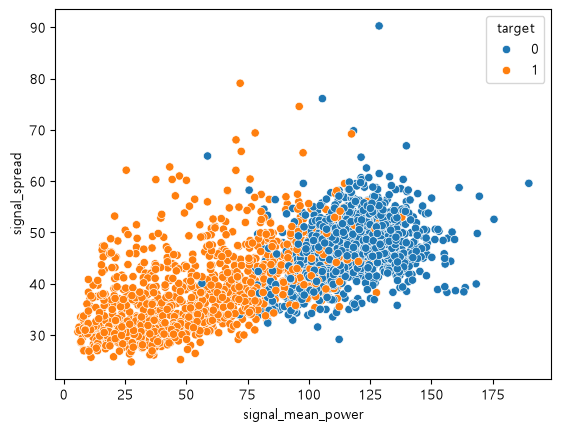

In [50]:
sns.scatterplot(star_df, x="signal_mean_power", y="signal_spread", hue="target")

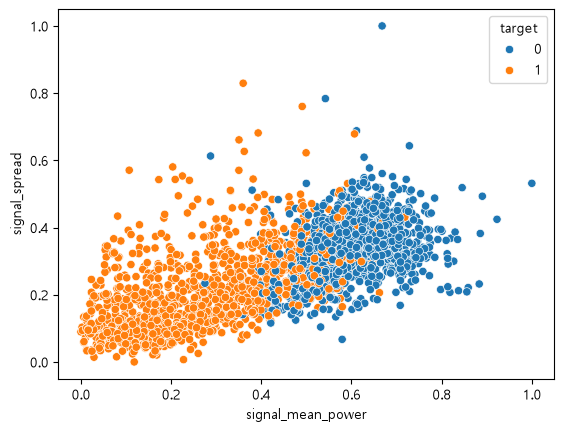

In [31]:
sns.scatterplot(star_df_scaled1, x="signal_mean_power", y="signal_spread", hue="target")
plt.show()

In [32]:
X = star_df_scaled.drop("target", axis=1)
y = star_df_scaled["target"]

In [33]:
X1 = star_df_scaled1.drop("target", axis=1)
y1 = star_df_scaled1["target"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

In [35]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, stratify=y, random_state=2026)

In [36]:
# 모델 준비

In [37]:
kn = KNeighborsClassifier()

In [38]:
# 모델 학습

In [39]:
kn.fit(X_train, y_train)

KNeighborsClassifier()

In [40]:
kn.fit(X1_train, y1_train)

KNeighborsClassifier()

In [41]:
# 모델 예측

In [42]:
y_pred = kn.predict(X_test)
print(y_pred)
print(list(y_test))

[1 1 0 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 0 1 0 0
 1 1 1 1 0 0 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 1
 0 1 0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 1
 0 0 0 1 0 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1
 0 1 0 0 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 1
 1 1 1 1 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 1 0 1 1
 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0
 1 0 1 1 0 1 0 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 0 1 1 1 0 1 1 1 0 0 1 0 1 1 0
 1 0 0 1 1 0 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 0 1
 1 1 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0
 0 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0
 0 1 1 0 1 1 0 0 1 0 1 1 1 0 0 1 1 1]
[1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1

In [43]:
y1_pred = kn.predict(X1_test)
print(y1_pred)
print(list(y1_test))

[1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 0 0 1 0 0
 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0
 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 1
 0 1 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0 0 1 1 0 1 0 1 1
 0 0 0 1 0 1 1 1 0 1 1 0 0 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1
 0 0 0 0 0 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 1 1 0 1 0 1
 1 0 1 1 0 1 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 1
 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0
 1 0 1 1 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 0
 1 0 0 1 1 0 1 0 0 0 1 1 0 1 0 1 1 1 1 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1
 1 0 1 1 0 1 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 0 0
 0 0 1 0 1 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0
 1 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1]
[1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1

In [44]:
# 모델 평가

In [45]:
accuracy_score(y_pred, y_test)

0.8225108225108225

In [46]:
accuracy_score(y1_pred, y1_test)

0.8961038961038961

In [47]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[165,  66],
       [ 16, 215]])

In [48]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["우주잡음(0)","별(1)"])

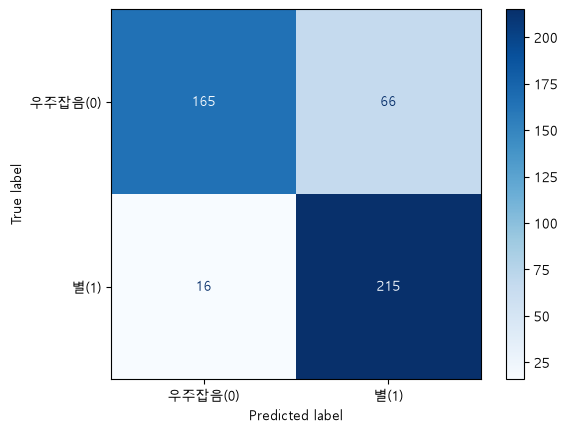

In [49]:
display.plot(cmap="Blues")
plt.show()

## 사이킷런 KNN 분류 사이클 실습

## 1단계. 데이터 전처리
- 데이터 정보(info) - 결측치 여부 확인, 데이터 타입(수치형, 분류형) 확인
- 데이터 기술 통계량(describe) - 4분위수, 이상치
- 데이터 EDA
- 결측치, 이상치 처리
- 표준화 또는 정규화

In [53]:
# .idxmin() : 가장 작은 값의 인덱스 가져옴
# 신호의 평균세기가 작은 데이터가 진짜 별
print(star_df.iloc[star_df["signal_mean_power"].idxmin()])
print(star_df.iloc[star_df["signal_mean_power"].idxmax()])

signal_mean_power     5.812500
signal_spread        30.631313
target                1.000000
Name: 557, dtype: float64
signal_mean_power    189.734375
signal_spread         59.578268
target                 0.000000
Name: 383, dtype: float64


In [55]:
# 스프레드가 작은 데이터가 진짜 별
print(star_df.iloc[star_df["signal_spread"].idxmin()])
print(star_df.iloc[star_df["signal_spread"].idxmax()])

signal_mean_power    27.546875
signal_spread        24.772042
target                1.000000
Name: 753, dtype: float64
signal_mean_power    128.656250
signal_spread         90.250557
target                 0.000000
Name: 1496, dtype: float64


In [56]:
star_df["target"] = star_df["target"].astype(int)
star_df

,signal_mean_power,signal_spread,target
0,138.820312,49.549602,0
1,25.437500,38.225636,1
2,34.023438,32.876299,1
3,101.093750,47.496289,0
4,101.945312,39.955309,0
...,...,...,...
2301,155.460938,39.429506,0
2302,126.000000,45.366046,0
2303,40.062500,30.721722,1
2304,40.929688,30.200937,1


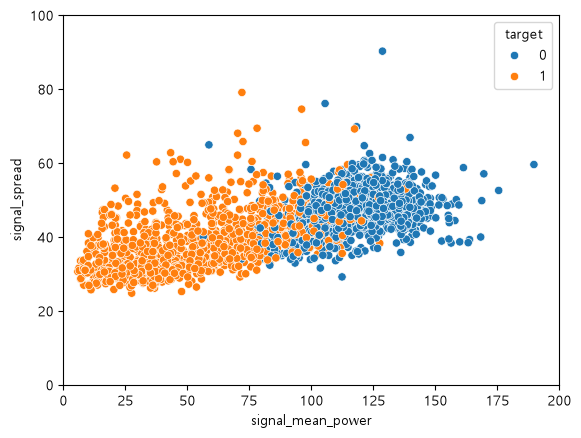

In [62]:
sns.scatterplot(star_df, x="signal_mean_power", y="signal_spread", hue="target")
plt.xlim(0,200)
plt.ylim(0,100)
plt.show()

<Axes: xlabel='target', ylabel='signal_mean_power'>

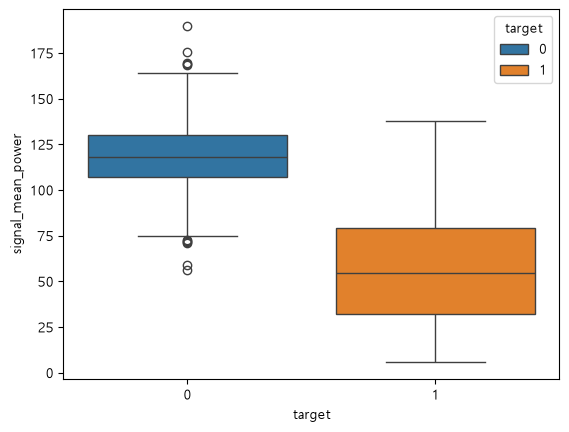

In [63]:
sns.boxplot(star_df, x="target", y="signal_mean_power", hue="target")

<Axes: xlabel='target', ylabel='signal_spread'>

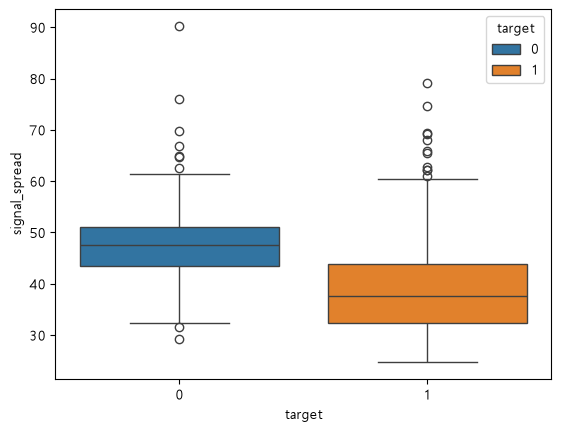

In [64]:
sns.boxplot(star_df, x="target", y="signal_spread", hue="target")

## 독립변수와 종속변수 준비

In [66]:
X = star_df.drop("target",axis=1)
X.head()

,signal_mean_power,signal_spread
0,138.820312,49.549602
1,25.437500,38.225636
2,34.023438,32.876299
3,101.093750,47.496289
4,101.945312,39.955309


In [67]:
y = star_df["target"]
y.head()

0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

In [71]:
# ※먼저 나누고 스케일하는 게 원칙※

In [70]:
scaler = StandardScaler()

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

In [76]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
X_train_scaled

array([[ 0.860412  ,  0.06373395],
       [-0.04156142, -0.42246395],
       [ 0.83172734, -0.72122983],
       ...,
       [ 0.32894887,  0.84999533],
       [-0.86226162, -1.22677755],
       [ 1.43271095,  0.12325785]], shape=(1844, 2))

## 2단계. 모델 준비

## 하이퍼 파라미터(Hyper Parameter)
- 사람(개발자 또는 분석가)가 필요에 따라 직접 설정하는 파라미터의 값을 의미한다.

## 파라미터(Parameter)
- 모델이 학습(fit)을 통해 스스로 찾아내는 값을 의미한다.

In [79]:
KNeighborsClassifier?

Init signature:
KNeighborsClassifier(
    n_neighbors=5,
    *,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None,
)
Docstring:     
Classifier implementing the k-nearest neighbors vote.

Read more in the :ref:`User Guide <classification>`.

Parameters
----------
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.

weights : {'uniform', 'distance'}, callable or None, default='uniform'
    Weight function used in prediction.  Possible values:

    - 'uniform' : uniform weights.  All points in each neighborhood
      are weighted equally.
    - 'distance' : weight points by the inverse of their distance.
      in this case, closer neighbors of a query point will have a
      greater influence than neighbors which are further away.
    - [callable] : a user-defined function which accepts an
      array of distances, and returns an array of the same shape

In [80]:
kn = KNeighborsClassifier(n_neighbors=5)

## 3단계. 모델 학습

In [81]:
kn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [84]:
# 모델 예측
y_pred = kn.predict(X_test_scaled)
y_pred[:10]

array([1, 1, 0, 0, 1, 1, 1, 1, 0, 1])

In [86]:
print(f"모델 점수: {accuracy_score(y_pred, y_test)}")

모델 점수: 0.8917748917748918


In [87]:
# 1~
train_scores = []
test_scores = []

for k in range(1,21):
    kn = KNeighborsClassifier(n_neighbors=k)
    kn.fit(X_train_scaled, y_train)

    train_scores.append(kn.score(X_train_scaled, y_train))
    test_scores.append(kn.score(X_test_scaled, y_test))

In [88]:
print(train_scores)
print(test_scores)

[1.0, 0.9235357917570499, 0.9273318872017353, 0.9126898047722343, 0.9181127982646421, 0.9094360086767896, 0.9061822125813449, 0.9072668112798264, 0.9072668112798264, 0.9045553145336226, 0.903470715835141, 0.9023861171366594, 0.9040130151843818, 0.9029284164859002, 0.903470715835141, 0.903470715835141, 0.903470715835141, 0.9013015184381779, 0.9029284164859002, 0.9029284164859002]
[0.8463203463203464, 0.8658008658008658, 0.8722943722943723, 0.8787878787878788, 0.8917748917748918, 0.8917748917748918, 0.8939393939393939, 0.8917748917748918, 0.8939393939393939, 0.8961038961038961, 0.8982683982683982, 0.8939393939393939, 0.8961038961038961, 0.8917748917748918, 0.8961038961038961, 0.9004329004329005, 0.9004329004329005, 0.9004329004329005, 0.8961038961038961, 0.8982683982683982]


In [93]:
train_k = train_scores.index(max(train_scores)) + 1
test_k = test_scores.index(max(test_scores)) + 1

print(f"훈련 데이터셋의 최적의 k 개수: {train_k}")
print(f"테스트 데이터셋의 최적의 k 개수: {test_k}")

훈련 데이터셋의 최적의 k 개수: 1
테스트 데이터셋의 최적의 k 개수: 16


In [96]:
new_data = pd.DataFrame([[50,60]], columns=["signal_mean_power", "signal_spread"])
new_data_scaled = scaler.transform(new_data)
new_data_scaled

array([[-0.9522996,  2.1075871]])

In [97]:
distances, indexes = kn.kneighbors(new_data_scaled)
distances, indexes

(array([[0.14349252, 0.1522329 , 0.38340163, 0.44379392, 0.48164563,
         0.54441506, 0.5785064 , 0.60211116, 0.64451649, 0.67791605,
         0.6886558 , 0.76642106, 0.78381163, 0.81218364, 0.83059155,
         0.83890081, 0.91526352, 0.91665189, 0.92678993, 0.94649019]]),
 array([[1839, 1794,  326,  899, 1419, 1838,  642,  601, 1278, 1384, 1484,
          245,  811, 1736, 1002,  276,  452, 1263,  506, 1781]]))

In [98]:
X_test_scaled

array([[-1.47280679e+00, -1.82536753e+00],
       [-6.16649154e-01, -6.55509205e-01],
       [ 1.75879984e+00, -5.67684735e-01],
       [ 6.37707435e-01, -1.69963534e+00],
       [-6.52903386e-01, -2.40281490e-01],
       [-1.78893572e+00, -1.84843155e+00],
       [-2.27613356e-01, -1.21680041e+00],
       [-1.98534601e+00, -8.47319047e-01],
       [ 9.23558111e-01,  1.07133097e+00],
       [-9.64849141e-01, -1.26531659e+00],
       [ 7.01251941e-01,  1.71474565e+00],
       [-7.71426837e-01, -4.54421675e-01],
       [ 5.93286041e-01,  3.74613530e-01],
       [ 9.28538088e-01,  6.60618449e-01],
       [-1.64391880e+00, -1.70197557e+00],
       [ 1.27375009e+00,  1.10464964e+00],
       [-9.49036688e-03,  6.57399970e-01],
       [ 4.69384215e-01,  7.49582585e-01],
       [-5.00516092e-01, -1.25235218e+00],
       [ 1.26562603e-01,  7.78007157e-02],
       [ 6.01054805e-01,  5.59693334e-01],
       [ 9.23956509e-01,  4.93129797e-01],
       [-4.76413004e-01, -3.67241914e-01],
       [-1.

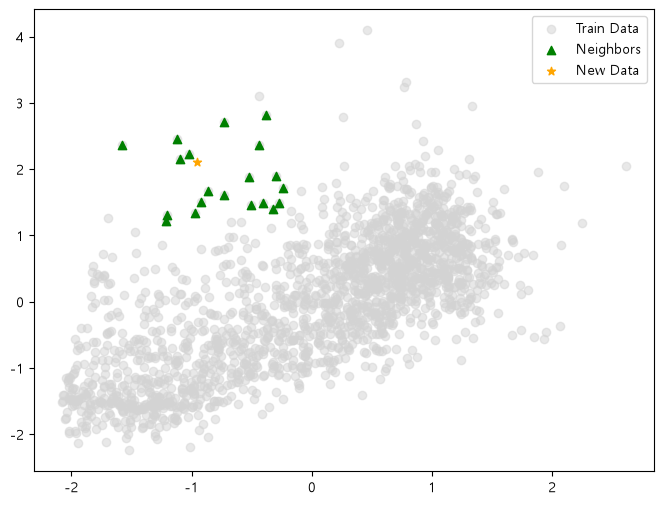

In [106]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c="lightgray", label="Train Data", alpha=0.5)

neighbor_data = X_train_scaled[indexes[0]]
plt.scatter(neighbor_data[:, 0], neighbor_data[:, 1], marker="^", color="green", label="Neighbors")
plt.scatter(new_data_scaled[0,0], new_data_scaled[0,1], marker="*", color="orange", label="New Data")
plt.legend()

plt.show()

In [107]:
kn.predict(new_data_scaled)

array([1])

## 4단계. 모델 평가

In [108]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[211,  20],
       [ 30, 201]])

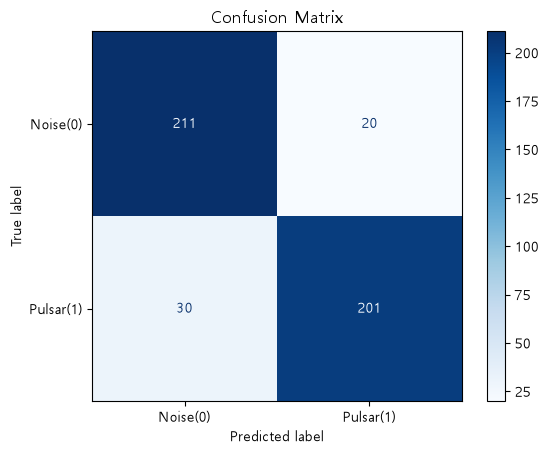

In [112]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Noise(0)", "Pulsar(1)"])
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [114]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       231
           1       0.91      0.87      0.89       231

    accuracy                           0.89       462
   macro avg       0.89      0.89      0.89       462
weighted avg       0.89      0.89      0.89       462

